In [1]:
import pandas as pd
import numpy as np
import os
import ast
import seaborn as sns
import matplotlib.pyplot as plt
import json
import math

### Informations : 

Pour chaque athlète, on a toutes ses activités. Pour chaque activité, si on a accès aux splits on les utilise car plus précis. On va donc utiliser les données communes aux activités et aux splits pour l'analyse.
Données utilisées :
1. Dans df_final : 

- sport_type (Run, Ride, Swim, Workout...)
- start_date
- athlete_id
- activity_id
- distance
- moving_time
- average_heartrate
- average_speed_km_h

2. Dans df_athletes_stats : (je rajoute les infos des athletes dont j'ai pas l'authorisation à la main)

- athlete_id (ou Nom Prénom à voir)
- Total_distance_run
- Total_distance_ride
- Total_distance_swim
- FC Max (?, ou que pour les athletes dans athletes.json)
- 5km PB --> + équivalent VDOT
- 10km PB --> + équivalent VDOT
- 21km PB --> + équivalent VDOT
- 42km PB --> + équivalent VDOT
- VDOT Max (correspondant à leur meilleur perf, pour "évaluer" leur niveau et le comparer aux autres athlètes)
- Nb_activities_run
- Nb_activities_ride
- Nb_activities_swim
- Nb_activities_workout
- Nb_activities

In [2]:
folder = "Data"
df = pd.concat([pd.read_csv(os.path.join(folder, f)) for f in os.listdir(folder) if f.endswith(".csv")], ignore_index=True) # Concat toutes les data dans un seul df
pd.set_option("display.max_colwidth", None)

In [3]:
# Suppression des colonnes inutiles
cols_to_drop = [
    'photo_count', 'from_accepted_tag', 'achievement_count', 'location_state', 'kudos_count', 'comment_count', 'map',
    'trainer', 'commute', 'flagged', 'start_latlng', 'end_latlng', 'upload_id', 'upload_id_str', 'external_id',
    'pr_count', 'total_photo_count', 'has_kudoed', 'location_country', 'location_city', 'start_date_local',
    'display_hide_heartrate_option', 'elapsed_time', 'utc_offset', 'device_watts', 'workout_type', 'type',
    'resource_state', 'timezone', 'elev_low', 'elev_high', 'manual', 'kilojoules', 'perceived_exertion',
    'prefer_perceived_exertion', 'segment_efforts', 'description', 'stats_visibility', 'hide_from_home', 'photos',
    'similar_activities', 'device_name', 'message', 'gear', 'gear_id', 'embed_token', 'errors', 'splits_standard',
    'has_heartrate', 'available_zones', 'private', 'visibility', 'heartrate_opt_out', 'calories', 'average_temp',
    'name', 'athlete_count', 'average_cadence', 'private_note', 'laps'
]
df = df.drop(columns=cols_to_drop, errors='ignore')

# Nettoyage colonne 'athlete'
df['athlete'] = df['athlete'].apply(ast.literal_eval)
df['athlete_id'] = df['athlete'].apply(lambda x: x['id'] if isinstance(x, dict) else None)
df = df.drop(columns=['athlete'])

# Renommage des colonnes
df = df.rename(columns={'id': 'activity_id'})

# Calculs sur les vitesses
df['moving_time'] = df['moving_time'] / 60  # minutes
df['average_speed_km_h'] = df['average_speed'] * 3.6
df['max_speed_km_h_activity'] = df['max_speed'] * 3.6
df = df.drop(columns=["average_speed", 'max_speed'])

# Conversion date
df['start_date'] = pd.to_datetime(df['start_date'])

# Renommage pour éviter conflits dans les splits
df = df.rename(columns={
    'distance': 'distance_activity',
    'moving_time': 'moving_time_activity',
    'average_speed_km_h': 'average_speed_km_h_activity',
    'average_heartrate': 'average_heartrate_activity',
    'total_elevation_gain': 'elevation_gain_activity',
    'max_heartrate': 'max_heartrate_activity',
    'average_watts': 'average_watts_activity',
    'max_watts': 'max_watts_activity',
    'weighted_average_watts': 'weighted_average_watts_activity'
})

# Tri par athlète et date
df = df.sort_values(by=['athlete_id', 'start_date'])

# Distances cumulées par sport
def cumulative_distance(df, sport):
    return (
        df.groupby('athlete_id', group_keys=False)
        .apply(lambda x: x.loc[x['sport_type'] == sport, 'distance_activity'].cumsum())
    )

df['cumulative_distance_run'] = cumulative_distance(df, 'Run')
df['cumulative_distance_ride'] = cumulative_distance(df, 'Ride')
df['cumulative_distance_swim'] = cumulative_distance(df, 'Swim')

# Traitement de splits_metric
df['splits_metric'] = df['splits_metric'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_splits_metric = df.explode("splits_metric").reset_index(drop=True)
df_splits_metric = pd.concat([df_splits_metric.drop(columns=["splits_metric"]), df_splits_metric["splits_metric"].apply(pd.Series)], axis=1)
df = df.drop(columns=["splits_metric"])

# Traitement des best_efforts
df['best_efforts'] = df['best_efforts'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_efforts = df[df['best_efforts'].apply(lambda x: isinstance(x, list) and len(x) > 0)].copy() # Supprimer les lignes sans best_efforts
df_best_efforts = df_efforts.explode("best_efforts").reset_index(drop=True) # Exploser et garder les colonnes utiles
df_best_efforts = pd.concat(
    [df_best_efforts.drop(columns=["best_efforts", 'start_date']), df_best_efforts["best_efforts"].apply(pd.Series)],
    axis=1
)
# Renommer/ajouter des colonnes utiles
df_best_efforts['elapsed_time_best_effort_min'] = df_best_efforts['elapsed_time'] / 60
df_best_efforts = df_best_efforts.rename(columns={
    'name': 'best_effort_name',
    'elapsed_time': 'elapsed_time_best_effort',
    'distance': 'distance_best_effort'
})

# Traitement de df_splits_metric
df_splits_metric['start_date'] = pd.to_datetime(df_splits_metric['start_date'])
df_splits_metric['average_speed_km_h'] = df_splits_metric['average_speed'] * 3.6
df_splits_metric = df_splits_metric.rename(columns={
    'distance': 'distance_split',
    'moving_time': 'moving_time_split',
    'average_speed': 'average_speed_split',
    'average_speed_km_h': 'average_speed_km_h_split',
    'average_heartrate': 'average_heartrate_split'
})
df_splits_metric = df_splits_metric.drop(columns=[
    'elapsed_time', 'elevation_difference', 0, 'average_grade_adjusted_speed',
    'cumulative_distance_swim', 'cumulative_distance_ride', 'cumulative_distance_run',
    'pace_zone', 'split'
], errors='ignore')

# Supprimer aussi les colonnes 'best_efforts' ou 'splits_metric' restantes dans les autres DataFrames (plus pratique)
for col in ['splits_metric', 'best_efforts']:
    for d in [df, df_splits_metric, df_best_efforts]:
        if col in d.columns:
            d.drop(columns=[col], inplace=True)

df_best_efforts = df_best_efforts.dropna(axis=0, subset = ['pr_rank'])  # Supprimer les lignes sans pr_rank
df_best_efforts = df_best_efforts.drop(columns=[
    'average_watts_activity', 'average_heartrate_activity', 'max_heartrate_activity',
    'start_date_local', 'start_index', 'end_index', 'pace_min_per_km', 'elevation_gain_activity',
    'elapsed_time_best_effort_min', 'athlete', 'activity', 'elapsed_time_best_effort', 
    'max_watts_activity', 'weighted_average_watts_activity', 'average_speed_km_h_activity',
    'max_speed_km_h_activity', 'cumulative_distance_run', 'cumulative_distance_ride', 
    'cumulative_distance_swim', 'resource_state', 'achievements'
], errors='ignore')
df_best_efforts['start_date'] = pd.to_datetime(df_best_efforts['start_date'])  # Reconvertir en datetime
df_best_efforts['moving_time'] = df_best_efforts['moving_time'] / 60  # minutes
df_best_efforts = df_best_efforts.drop(            # On ne garde que les records sur 5, 10, 21 et 42km
    df_best_efforts[
        (df_best_efforts['best_effort_name'] == '2 mile') |
        (df_best_efforts['best_effort_name'] == '1/2 mile') |
        (df_best_efforts['best_effort_name'] == '10 mile') |
        (df_best_efforts['best_effort_name'] == '1K') |
        (df_best_efforts['best_effort_name'] == '400m') |
        (df_best_efforts['best_effort_name'] == '15K') |
        (df_best_efforts['best_effort_name'] == '1 mile')
    ].index
)
  

C:\Users\Mathi\AppData\Local\Temp\ipykernel_13536\4267833499.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x['sport_type'] == sport, 'distance_activity'].cumsum())
C:\Users\Mathi\AppData\Local\Temp\ipykernel_13536\4267833499.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x['sport_type'] == sport, 'distance_activity'].cumsum())
C:\Users\Mathi\AppData

In [4]:
# Étape 1 : activités qui n'ont pas de splits
df_activity_no_splits = df_splits_metric[df_splits_metric['distance_split'].isnull()].copy()

# Étape 2 : activités qui ont des splits
df_activity_only_splits = df_splits_metric[df_splits_metric['distance_split'].notnull()].copy()

# Étape 3 : On enlève toutes les colonnes liées aux splits dans df_activity_no_splits et pareil pour les colonnes liées aux acitvités dans df_activity_only_splits
df_activity_only_splits = df_activity_only_splits.drop(columns=[col for col in df_activity_only_splits.columns if 'activity' in col and col != 'activity_id'], errors='ignore') # On garde 'activity_id' pour la fusion
df_activity_no_splits = df_activity_no_splits.drop(columns=[col for col in df_activity_no_splits.columns if 'split' in col], errors='ignore')

# Étape 4 : On renomme les colonnes pour avoir les mêmes dans les deux dataframes
df_activity_only_splits = df_activity_only_splits.rename(columns={
    'distance_split': 'distance',
    'moving_time_split': 'moving_time',
    'average_speed_km_h_split': 'average_speed_km_h',
    'average_heartrate_split': 'average_heartrate'
})
df_activity_only_splits = df_activity_only_splits.drop(columns=['average_speed_split'])

df_activity_no_splits = df_activity_no_splits.rename(columns={
    'distance_activity': 'distance',
    'moving_time_activity': 'moving_time',
    'average_speed_km_h_activity': 'average_speed_km_h',
    'average_heartrate_activity': 'average_heartrate'
})
df_activity_no_splits = df_activity_no_splits.drop(columns=[col for col in df_activity_no_splits.columns if col not in df_activity_only_splits.columns], errors='ignore') # On garde 'activity_id' pour la fusion

# Étape 5 : On fusionne les deux dataFrames pour avoir notre df final
df_final = pd.concat([df_activity_no_splits, df_activity_only_splits], ignore_index=True)
df_final.dropna(axis=0, subset=['average_heartrate'], inplace=True) # Supprimer les lignes sans average_heartrate
df_final.shape

(36741, 9)

In [5]:
# On crée un dataFrame pour stocker les stats des athlètes
df_athletes_stats = pd.DataFrame(columns=['athlete_id', 'Total_distance_run', 'Total_distance_ride', 'Total_distance_swim', 'FC Max', '5km PB', '10km PB', '21km PB',
                                        '42km PB', 'Nb_activities', 'Nb_activities_run', 'Nb_activities_ride', 'Nb_activities_swim'])
df_athletes_stats['Nb_activities_run'] = df_final[df_final['sport_type']=='Run'].groupby('athlete_id')['activity_id'].nunique() # On compte le nombre d'activités par athlète pour chaque sport
df_athletes_stats['Nb_activities_ride'] = df_final[df_final['sport_type']=='Ride'].groupby('athlete_id')['activity_id'].nunique()
df_athletes_stats['Nb_activities_swim'] = df_final[df_final['sport_type']=='Swim'].groupby('athlete_id')['activity_id'].nunique()
df_athletes_stats['Nb_activities_workout'] = df_final[df_final['sport_type']=='Workout'].groupby('athlete_id')['activity_id'].nunique()

df_athletes_stats['athlete_id'] = df_final['athlete_id'].unique() # On ajoute les IDs des athlètes

# On regarde les distances totales parcourues par chaque athlète pour chaque sport
total_distance_run = df_final[df_final['sport_type']=='Run'].groupby('athlete_id')['distance'].sum()
total_distance_ride = df_final[df_final['sport_type']=='Ride'].groupby('athlete_id')['distance'].sum()
total_distance_swim = df_final[df_final['sport_type']=='Swim'].groupby('athlete_id')['distance'].sum()
df_athletes_stats['Total_distance_run'] = df_athletes_stats['athlete_id'].map(total_distance_run)
df_athletes_stats['Total_distance_ride'] = df_athletes_stats['athlete_id'].map(total_distance_ride)
df_athletes_stats['Total_distance_swim'] = df_athletes_stats['athlete_id'].map(total_distance_swim)

# On regarde la FC max de chaque athlète (onf fait la moyenne sur les 10 plus hautes FC max, sans compter celles >210 bpm)
fc_valides = df[df["max_heartrate_activity"] < 210].groupby('athlete_id')["max_heartrate_activity"].apply(lambda x: x.nlargest(10).mean())
df_athletes_stats['FC Max'] = df_athletes_stats['athlete_id'].map(fc_valides)

def extract_best_effort_time(df_best_efforts, distance_km):
    return (
        df_best_efforts[df_best_efforts['distance_best_effort'].between((distance_km - 0.2)*1000, (distance_km + 0.2)*1000)]
        .groupby('athlete_id')['moving_time']
        .min()
        .round(2)
    )

df_athletes_stats['5km PB'] = df_athletes_stats['athlete_id'].map(extract_best_effort_time(df_best_efforts, 5))
df_athletes_stats['10km PB'] = df_athletes_stats['athlete_id'].map(extract_best_effort_time(df_best_efforts, 10))
df_athletes_stats['21km PB'] = df_athletes_stats['athlete_id'].map(extract_best_effort_time(df_best_efforts, 21.1))
df_athletes_stats['42km PB'] = df_athletes_stats['athlete_id'].map(extract_best_effort_time(df_best_efforts, 42.2))

In [6]:
# Charger les stats ajoutées manuellement
manual_stats = pd.read_csv("manual_stats.csv")

# Réorganiser les colonnes selon les colonnes présentes au moment du chargement
common_columns = [col for col in df_athletes_stats.columns if col in manual_stats.columns]
manual_stats = manual_stats[common_columns]

# Concaténer les deux DataFrames (pandas remplira les colonnes manquantes avec NaN)
df_athletes_stats = pd.concat([df_athletes_stats, manual_stats], ignore_index=True)

df_athletes_stats = df_athletes_stats.drop_duplicates(subset='athlete_id', keep='last') # On enlève les doublons (au cas où)

# Puis preprocessing de tout de dataframe
df_athletes_stats['Nb_activities_run'] = df_athletes_stats['Nb_activities_run'].fillna(0)
df_athletes_stats['Nb_activities_ride'] = df_athletes_stats['Nb_activities_ride'].fillna(0)
df_athletes_stats['Nb_activities_swim'] = df_athletes_stats['Nb_activities_swim'].fillna(0)
df_athletes_stats['Nb_activities_workout'] = df_athletes_stats['Nb_activities_workout'].fillna(0)
df_athletes_stats['Total_distance_run'] = df_athletes_stats['Total_distance_run'].fillna(0)
df_athletes_stats['Total_distance_ride'] = df_athletes_stats['Total_distance_ride'].fillna(0)
df_athletes_stats['Total_distance_swim'] = df_athletes_stats['Total_distance_swim'].fillna(0)
df_athletes_stats['Nb_activities'] = df_athletes_stats['Nb_activities_run'] + df_athletes_stats['Nb_activities_ride'] + df_athletes_stats['Nb_activities_swim'] + df_athletes_stats['Nb_activities_workout']


# On transforme chaque PB en son score VDOT équivalent (approximation) pour mieux comparer les performances
def calculate_vdot(distance_m, time_sec):
    time_min = time_sec / 60
    if time_min == 0:
        return None

    velocity = distance_m / time_min  # m/min
    vo2 = -4.6 + 0.182258 * velocity + 0.000104 * velocity**2

    percent_max = 0.8 + 0.1894393 * math.exp(-0.012778 * time_min) + \
                  0.2989558 * math.exp(-0.1932605 * time_min)

    vdot = vo2 / percent_max
    return round(vdot, 2)

for dist, colname in [(5000, '5km PB'), (10000, '10km PB'), (21100, '21km PB'), (42200, '42km PB')]:
    vdot_col = f'VDOT_{colname.split()[0]}'
    df_athletes_stats[vdot_col] = df_athletes_stats.apply(
        lambda row: calculate_vdot(dist, row[colname]*60) if pd.notna(row[colname]) else None, axis=1)

# Puis on créer la variable VDOT max pour "noter" les athlètes et standardiser les performances
df_athletes_stats['VDOT_max'] = df_athletes_stats[['VDOT_5km', 'VDOT_10km', 'VDOT_21km', 'VDOT_42km']].max(axis=1)

In [7]:
    # On crée une variable 'cv_speed' qui correspond au Coefficient de variabilité de la vitesse pour chaque activité (pour + différencier les séances de fractionné par exemple: si cv élevé, ça signifie
    # que l'athlète a beaucoup varié sa vitesse, donc il a fait du fractionné, si cv faible, il a fait une sortie à allure constante)
    # On crée aussi une variable zone qui correspond à la zone cardiaque (Z1, Z2, Z3, Z4) pour chaque activité (j'ai utilisé le modèle de ... (article de Leif Inge Tjelta) pour les zones, en combinant Z4 et Z5)
    # FAIRE LA MEME CHOSE POUR LA VITESSE ????
def process_splits(splits_df, fc_max_dict):
    #  Prend en entrée :
    # - splits_df : un DataFrame contenant les splits des activités (avec les colonnes 'activity_id', 'athlete_id', 'average_heartrate', 'average_speed_km_h')
    # - fc_max_dict : un dictionnaire {athlete_id: fc_max}
    # Retourne :
    # - Un DataFrame avec pour chaque activité :
    #     - cv_speed : coefficient de variation de la vitesse
    #     - pct_Z1 à pct_Z4 : pourcentage de temps passé dans chaque zone de FC 
     splits_df = splits_df.copy()

    # On défini les seuils de zones de FC en pourcentage de la FC max
     def get_hr_zone(hr, fc_max):
        if pd.isna(hr) or pd.isna(fc_max):
            return None
        ratio = hr / fc_max
        if ratio < 0.82:
            return "Z1"
        elif ratio < 0.92:
            return "Z2"
        elif ratio < 0.97:
            return "Z3"
        else:
            return "Z4"

    # Appliquer la zone cardiaque à chaque ligne
     splits_df["fc_max"] = splits_df["athlete_id"].map(fc_max_dict)
     splits_df["hr_zone"] = splits_df.apply(lambda row: get_hr_zone(row["average_heartrate"], row["fc_max"]), axis=1)

     results = []
     for activity_id, group in splits_df.groupby("activity_id"):
        # Coefficient de variation de la vitesse
        cv_speed = group["average_speed_km_h"].std() / group["average_speed_km_h"].mean()

        # Pourcentage par zone cardiaque
        zone_pct = group["hr_zone"].value_counts(normalize=True).reindex(["Z1", "Z2", "Z3", "Z4"], fill_value=0)
        zone_pct.index = [f"pct_{z}" for z in zone_pct.index]

        res = {"activity_id": activity_id, "cv_speed": cv_speed}
        res.update(zone_pct.to_dict())
        results.append(res)

     return pd.DataFrame(results)


# On crée un dictionnaire pour stocker les FC max de chaque athlète
fc_max_dict = df_athletes_stats.set_index("athlete_id")["FC Max"].to_dict()
# On applique la fonction sur le df des splits/activités
df_processed_splits = process_splits(df_final, fc_max_dict)
# Puis on fusionne
df_final = df_final.merge(df_processed_splits, on="activity_id", how="left")
df_final['cv_speed'].fillna(0, inplace=True) # On suppose que les activités entières (sans splits) ont un cv de 0 donc à allure constante


C:\Users\Mathi\AppData\Local\Temp\ipykernel_13536\3187885701.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['cv_speed'].fillna(0, inplace=True) # On suppose que les activités entières (sans splits) ont un cv de 0 donc à allure constante


In [8]:
df_final.tail(5)
# df_final.shape

,distance,moving_time,sport_type,activity_id,start_date,average_heartrate,athlete_id,suffer_score,average_speed_km_h,cv_speed,pct_Z1,pct_Z2,pct_Z3,pct_Z4
36736,998.7,349.0,Run,14570093869,2025-05-23 12:09:10+00:00,159.220630,146587351,NaN,10.296,0.049488,0.857143,0.142857,0.0,0.0
36737,999.9,347.0,Run,14570093869,2025-05-23 12:09:10+00:00,159.731214,146587351,NaN,10.368,0.049488,0.857143,0.142857,0.0,0.0
36738,1002.0,339.0,Run,14570093869,2025-05-23 12:09:10+00:00,156.731563,146587351,NaN,10.656,0.049488,0.857143,0.142857,0.0,0.0
36739,998.6,336.0,Run,14570093869,2025-05-23 12:09:10+00:00,156.348214,146587351,NaN,10.692,0.049488,0.857143,0.142857,0.0,0.0
36740,196.2,68.0,Run,14570093869,2025-05-23 12:09:10+00:00,156.485294,146587351,NaN,10.404,0.049488,0.857143,0.142857,0.0,0.0


In [9]:
df_final_by_activity = df_final[['athlete_id', 'activity_id', 'start_date', 'cv_speed', 'pct_Z1', 'pct_Z2', 'pct_Z3', 'pct_Z4', 'sport_type']].copy() # On garde que les colonnes utiles pour regrouper par activités
df_final_by_activity['distance'] = df_final.groupby('activity_id')['distance'].transform('sum')
df_final_by_activity['moving_time'] = df_final.groupby('activity_id')['moving_time'].transform('sum')
df_final_by_activity = df_final_by_activity.drop_duplicates(subset='activity_id') # On enlève les doublons (car plusieurs splits pour une même activité)

# On ajoute les variables "Intensité" et "Charge d'entraînement" (à ajuster)
# Autre option : training_load = intensity * moving_time * (1 + average_speed_km_h / 20)
# un truc du genre pour prendre en compte la vitesse
# OU internal load avec FC, cv_speed... et external load avec distance/moving_time, vitesse...
df_final_by_activity['intensity'] = (df_final_by_activity["pct_Z1"] * 1 + df_final_by_activity["pct_Z2"] * 1.5 + df_final_by_activity["pct_Z3"] * 2.25 + df_final_by_activity["pct_Z4"] * 3) #+ df_final_by_activity['cv_speed'] * 2
df_final_by_activity['training_load'] = df_final_by_activity['intensity'] * df_final_by_activity['distance']

df_final_by_activity.tail()

,athlete_id,activity_id,start_date,cv_speed,pct_Z1,pct_Z2,pct_Z3,pct_Z4,sport_type,distance,moving_time,intensity,training_load
36672,146587351,14509219942,2025-05-17 13:22:13+00:00,0.052175,0.571429,0.428571,0.0,0.0,Run,13863.7,4482.0,1.214286,16834.492857
36686,146587351,14522126885,2025-05-18 16:12:35+00:00,0.033464,1.000000,0.000000,0.0,0.0,Run,13254.8,4357.0,1.000000,13254.800000
36700,146587351,14541386570,2025-05-20 15:50:56+00:00,0.167647,0.727273,0.272727,0.0,0.0,Run,10801.5,3398.0,1.136364,12274.431818
36711,146587351,14553984189,2025-05-21 17:35:58+00:00,0.049446,1.000000,0.000000,0.0,0.0,Run,15181.6,5470.0,1.000000,15181.600000
36727,146587351,14570093869,2025-05-23 12:09:10+00:00,0.049488,0.857143,0.142857,0.0,0.0,Run,13197.2,4608.0,1.071429,14139.857143


In [10]:
df_athletes_stats.head()
# df_athletes_stats.shape

,athlete_id,Total_distance_run,Total_distance_ride,Total_distance_swim,FC Max,5km PB,10km PB,21km PB,42km PB,Nb_activities,Nb_activities_run,Nb_activities_ride,Nb_activities_swim,Nb_activities_workout,VDOT_5km,VDOT_10km,VDOT_21km,VDOT_42km,VDOT_max
0,44410997,3378375.9,4975555.3,62286.9,200.0,17.92,38.32,83.80,NaN,717.0,515,150.0,38.0,14.0,56.61,54.62,55.36,NaN,56.61
1,45632458,3272758.9,19607902.2,0.0,191.9,23.40,47.10,103.35,NaN,623.0,294,329.0,0.0,0.0,41.42,42.91,43.44,NaN,43.44
2,111468957,3242488.5,2013697.7,39343.2,204.2,19.40,41.15,NaN,NaN,160.0,137,23.0,0.0,0.0,51.61,50.25,NaN,NaN,51.61
3,118945026,2937667.4,621087.1,57301.2,198.2,18.40,37.25,86.37,191.43,450.0,336,69.0,43.0,2.0,54.90,56.46,53.47,49.77,56.46
4,146587351,1706622.0,0.0,3900.0,203.8,19.90,43.70,109.25,NaN,419.0,282,77.0,58.0,2.0,50.10,46.84,40.71,NaN,50.10


In [11]:
df_run = df_final_by_activity[df_final_by_activity['sport_type'] == 'Run'] # On divise on 4 datasets, pour chaque type d'activité
df_bike = df_final_by_activity[df_final_by_activity['sport_type'] == 'Ride']
df_swim = df_final_by_activity[df_final_by_activity['sport_type'] == 'Swim']
df_workout = df_final_by_activity[df_final_by_activity['sport_type'] == 'Workout']

In [12]:
df_run = df_run.drop(columns = ['sport_type'])
df_bike = df_bike.drop(columns = ['sport_type'])
df_swim = df_swim.drop(columns = ['sport_type'])
df_workout = df_workout.drop(columns = ['sport_type'])

In [13]:
total_distance = df_final_by_activity.groupby('athlete_id')['distance'].sum()
total_distance = pd.DataFrame(total_distance).reset_index()
total_distance = total_distance.rename(columns = {0 : 'total_distance'})
total_distance

,athlete_id,distance
0,44410997,9954207.2
1,45632458,24068782.1
2,59727232,1968761.3
3,111468957,5295776.4
4,118945026,3741449.0
5,122317319,35826.9
6,146587351,1725595.7


In [14]:
unique_counts = df_final_by_activity.nunique().sort_values(ascending=False) # Compte le nombre de valeurs uniques dans chaque colonne
df_unique = pd.DataFrame({'Colonne': unique_counts.index, 'Valeurs Uniques': unique_counts.values})
print(df_unique)

          Colonne  Valeurs Uniques
0     activity_id             2856
1      start_date             2837
2   training_load             2517
3        distance             2485
4     moving_time             2447
5        cv_speed             1961
6       intensity              354
7          pct_Z1              289
8          pct_Z2              288
9          pct_Z3               52
10         pct_Z4               19
11     sport_type               16
12     athlete_id                7


In [15]:
missing_values_count = df_run.isnull().sum() # Compte le nombre de valeurs nulles pour chaque variable
missing_values_count.sort_values(ascending=False)

athlete_id       0
activity_id      0
start_date       0
cv_speed         0
pct_Z1           0
pct_Z2           0
pct_Z3           0
pct_Z4           0
distance         0
moving_time      0
intensity        0
training_load    0
dtype: int64

In [16]:
df_values = df_best_efforts[df_best_efforts['athlete_id'] == 118945026]["best_effort_name"].value_counts().reset_index() # Compte le nombre d'occcurences différentes pour chaque valeur d'une certaine variable
df_values.columns = ["Valeur", "Occurrences"]
df_values.sort_values(by='Valeur', ascending = False).head(10)

,Valeur,Occurrences
5,Marathon,3
2,Half-Marathon,7
0,5K,11
3,30K,4
4,20K,4
1,10K,9


## #1 Running activites analysis ###

### Univariate analysis (activities)

In [17]:
df_run.dtypes

athlete_id                     int64
activity_id                    int64
start_date       datetime64[ns, UTC]
cv_speed                     float64
pct_Z1                       float64
pct_Z2                       float64
pct_Z3                       float64
pct_Z4                       float64
distance                     float64
moving_time                  float64
intensity                    float64
training_load                float64
dtype: object

In [18]:
df_run.shape

(1757, 12)

In [19]:
unique_counts_run = df_run.nunique().sort_values(ascending=False)
df_unique_run = pd.DataFrame({'Colonne': unique_counts_run.index, 'Valeurs Uniques': unique_counts_run.values})
print(df_unique_run)

          Colonne  Valeurs Uniques
0     activity_id             1757
1   training_load             1754
2      start_date             1740
3        distance             1726
4     moving_time             1518
5        cv_speed             1370
6       intensity              173
7          pct_Z1              111
8          pct_Z2              109
9          pct_Z3               46
10         pct_Z4               18
11     athlete_id                7


In [20]:
numerical_var = df_run[['average_heartrate', 'distance', 'moving_time', 'average_speed_km_h']]

fig = plt.figure(figsize=(18, 16))

for index, col in enumerate(numerical_var.columns, 1):
    plt.subplot(3, 2, index)
    sns.histplot(df_run[col].dropna(), kde=False, bins=50)
    plt.title(col)

fig.tight_layout(pad=1.0)
plt.show()

KeyError: "['average_heartrate', 'average_speed_km_h'] not in index"

In [ ]:
# categorical_var = df_run.select_dtypes(exclude=['number'])
# categorical_var = categorical_var.drop(columns=['start_date'])
# fig = plt.figure(figsize=(18, 16))

# for index, col in enumerate(categorical_var.columns, 1):
#     plt.subplot(6, 4, index)
#     sns.countplot(df_run[col])
#     plt.xticks(rotation = 90)
#     plt.title(col)

# fig.tight_layout(pad=1.0)
# plt.show()

### Univariate analysis (athletes_stats)

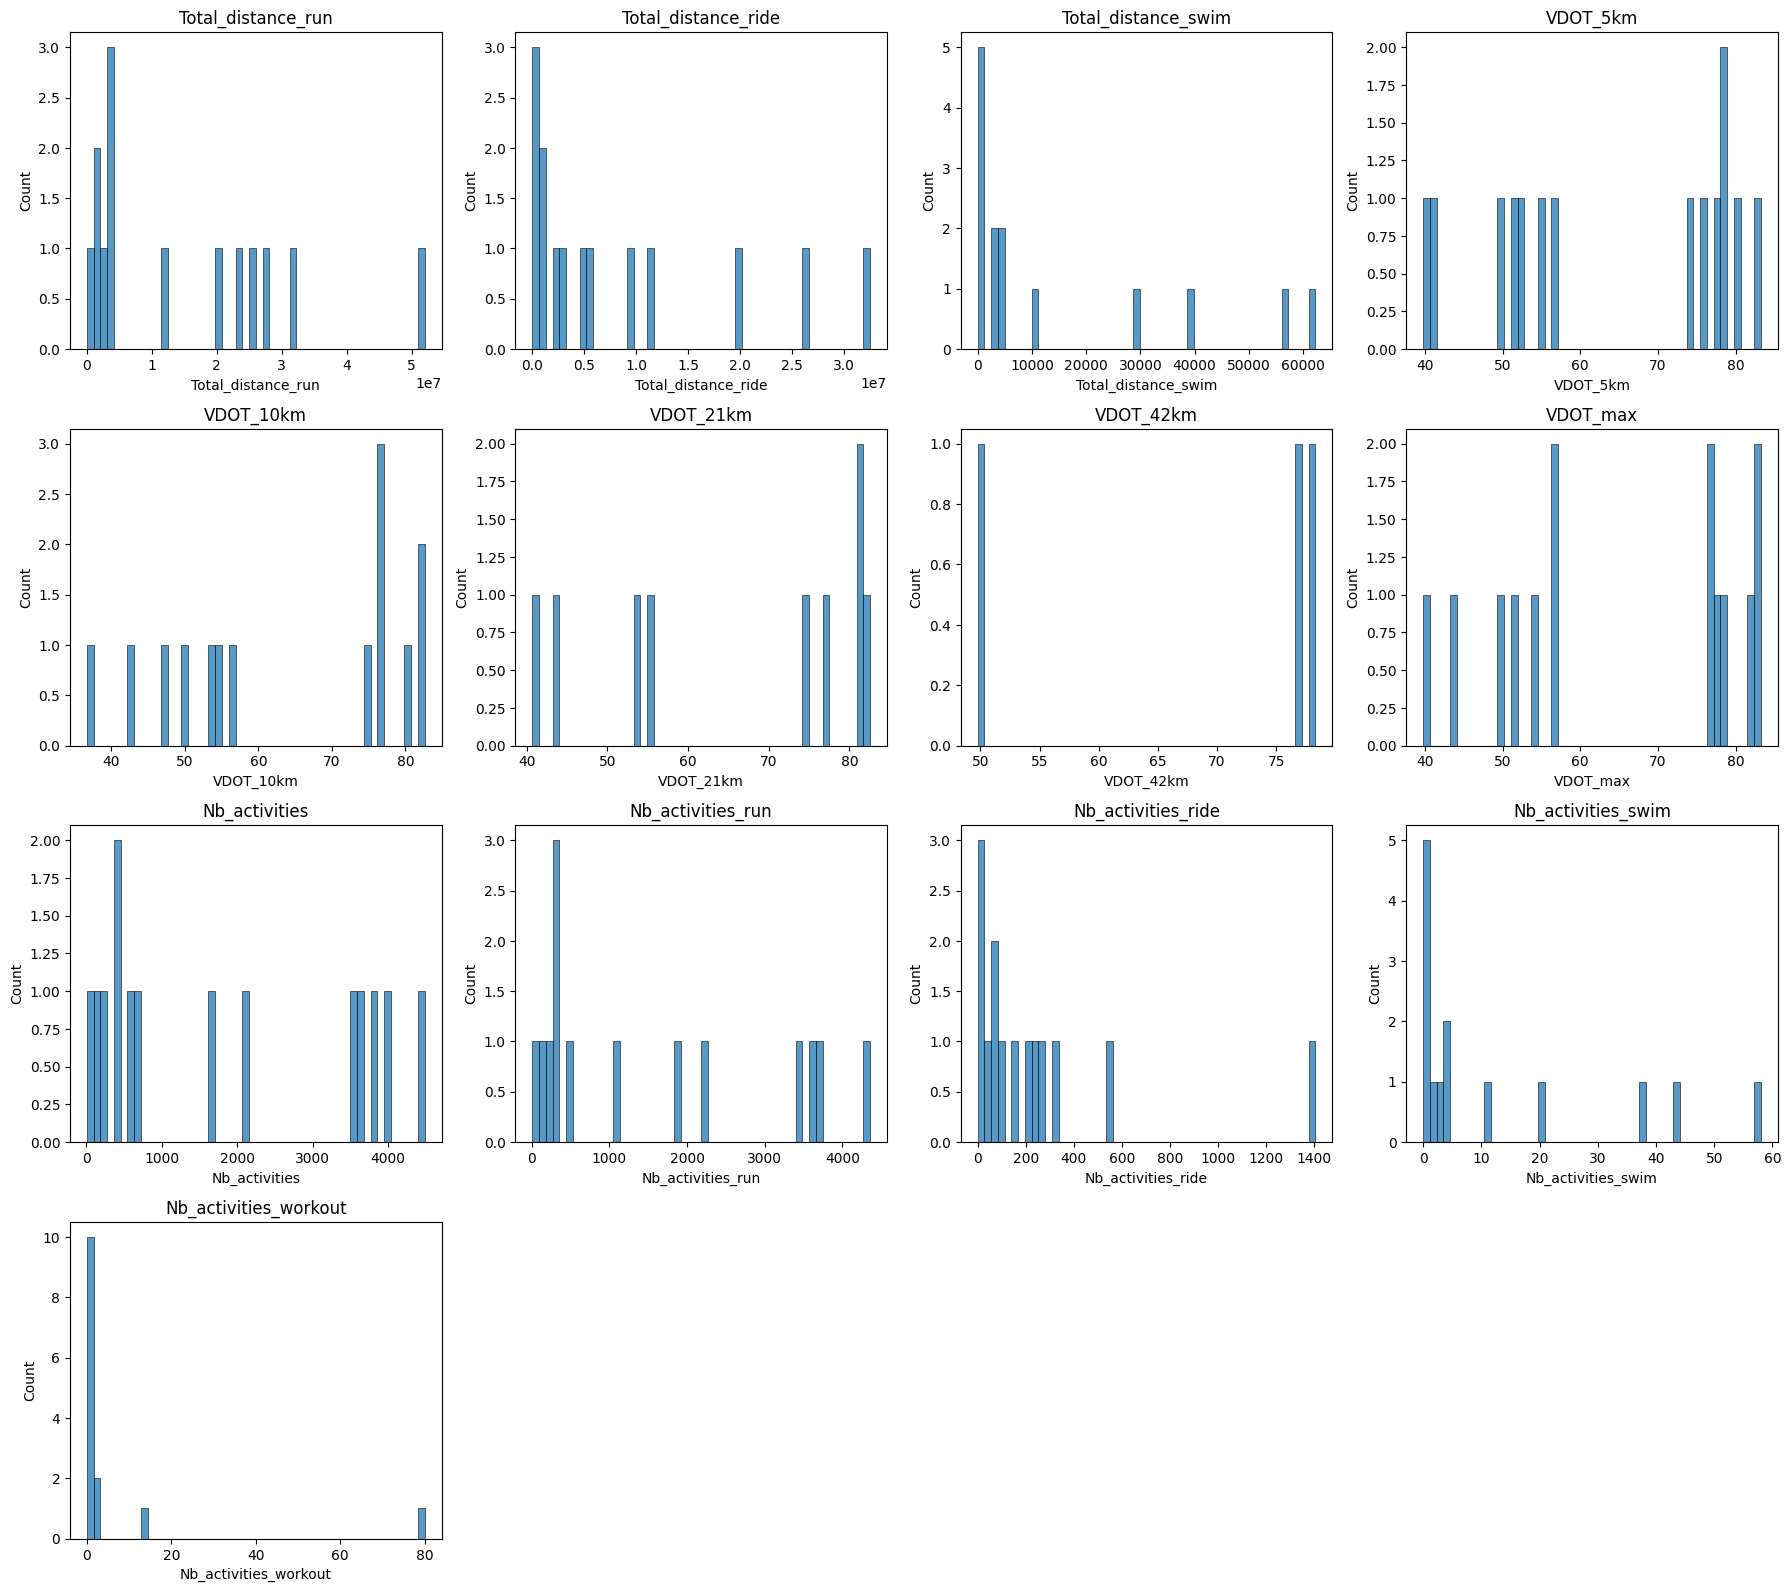

In [21]:
numerical_var2 = df_athletes_stats[['Total_distance_run', 'Total_distance_ride', 'Total_distance_swim', 'VDOT_5km', 'VDOT_10km', 'VDOT_21km', 'VDOT_42km', 'VDOT_max',
                                     'Nb_activities', 'Nb_activities_run', 'Nb_activities_ride', 'Nb_activities_swim', 'Nb_activities_workout']]

fig = plt.figure(figsize=(18, 16))

for index, col in enumerate(numerical_var2.columns, 1):
    plt.subplot(4, 4, index)
    sns.histplot(df_athletes_stats[col].dropna(), kde=False, bins=50)
    plt.title(col)

fig.tight_layout(pad=1.0)
plt.show()

### Bivariate analysis

<Axes: >

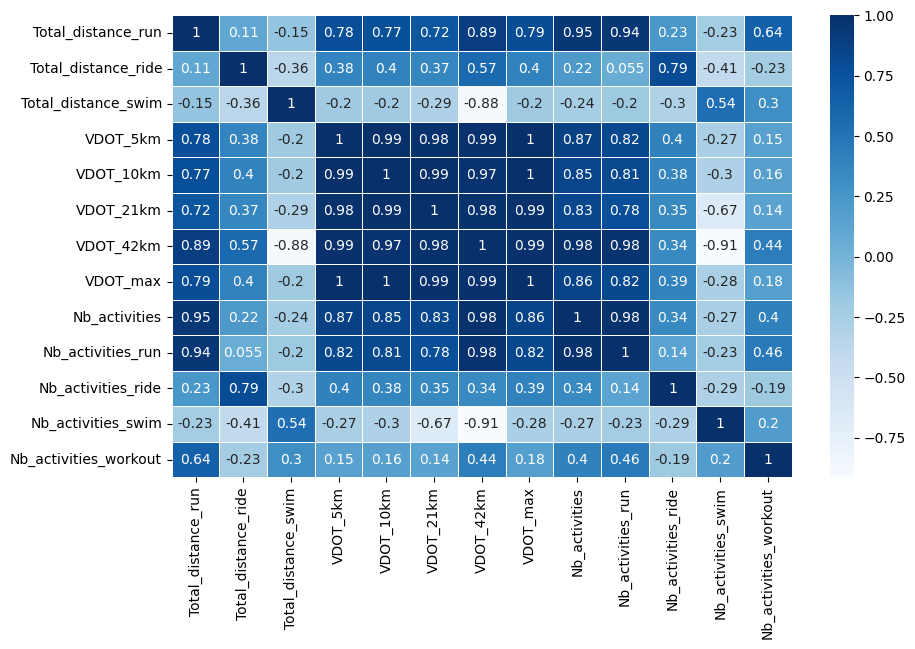

In [22]:
plt.figure(figsize=(10,6))
correlation = numerical_var2.corr()
sns.heatmap(correlation, linewidths=0.5, cmap='Blues', annot=True)

### Clustering

In [23]:
# Ici on va essayer de faire du clustering sur toutes les séances des athlètes : différencier les séances d'EF, seuil, fractio etc...
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [24]:
X = df_run[['activity_id', 'cv_speed', 'pct_Z1', 'pct_Z2', 'pct_Z3', 'pct_Z4', 'intensity', 'training_load', 'distance']]
X = X.drop_duplicates(subset='activity_id') # On enlève les doublons (caar plusieurs splits pour une même activité)
X = X.drop(columns=['activity_id'])

X_scaled = StandardScaler().fit_transform(X) # On normalise les données car les unités sont différentes

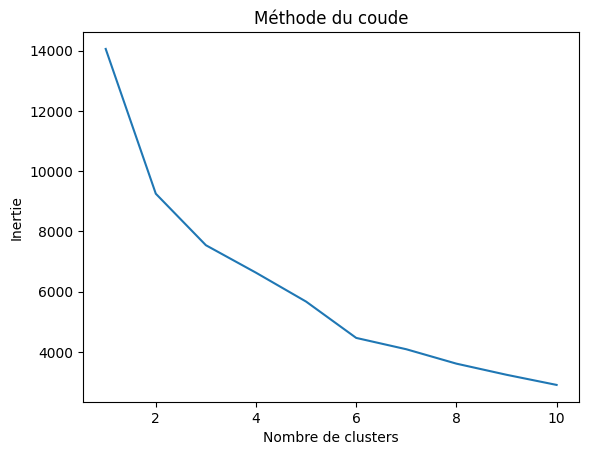

In [25]:
inertias = []
for i in range(1, 11): # Méthode du coude pour trouver k (nb de clusters optimal)
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(range(1, 11), inertias)
plt.title('Méthode du coude')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.show()

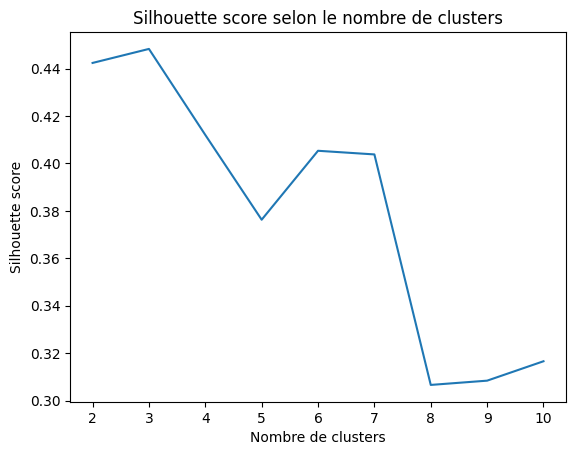

In [26]:
silhouette_scores = []
for i in range(2, 11):  # On teste aussi avec la méthode des silhouettes (on recherche le meilleur score)
    kmeans = KMeans(n_clusters=i, random_state=0)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores)
plt.title('Silhouette score selon le nombre de clusters')
plt.xlabel('Nombre de clusters')
plt.ylabel('Silhouette score')
plt.show()

### Interprétation des clusters

In [27]:
# Ici K=5 semble le plus pertinent
kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X_scaled)

In [28]:
X['cluster'] = kmeans.labels_
cluster_summary = X.groupby('cluster').mean()
display(cluster_summary)

,cv_speed,pct_Z1,pct_Z2,pct_Z3,pct_Z4,intensity,training_load,distance
cluster,,,,,,,,
0,0.059475,0.935707,0.063335,0.000729,0.000229,1.033037,7903.594881,7653.480605
1,0.069564,0.275569,0.679003,0.044105,0.001324,1.397280,15509.148109,11305.058266
2,0.093046,0.125498,0.177543,0.235054,0.461905,2.306399,14688.184613,6357.620000


In [29]:
df_clusters = df_run[['activity_id', 'athlete_id']].drop_duplicates()
df_clusters['cluster'] = kmeans.labels_

# On groupe par athlète pour voir les proportions de ses activités dans chaque cluster
df_clusters.groupby('athlete_id')['cluster'].value_counts(normalize=True).unstack().fillna(0)


cluster,0,1,2
athlete_id,,,
44410997,0.910680,0.087379,0.001942
45632458,0.173469,0.826531,0.000000
59727232,0.562044,0.423358,0.014599
111468957,0.562500,0.437500,0.000000
118945026,0.748227,0.248227,0.003546
122317319,0.000000,0.428571,0.571429
146587351,0.682796,0.306452,0.010753


In [30]:
X['cluster'].value_counts() # Nombre d'activités par cluster

cluster
0    1124
1     623
2      10
Name: count, dtype: int64

<Axes: xlabel='PC1', ylabel='PC2'>

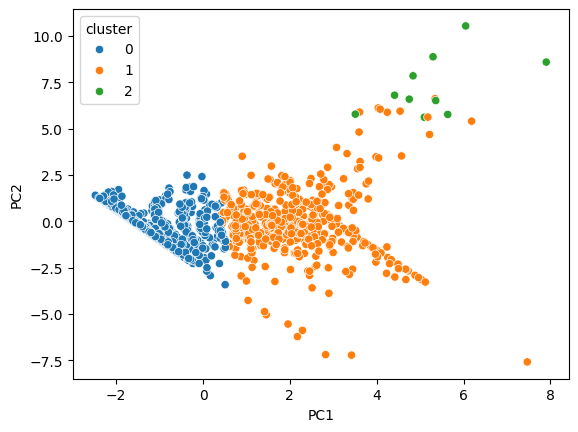

In [31]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_plot['cluster'] = kmeans.labels_

sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='cluster', palette='tab10')

In [33]:
X.sort_values(by='training_load').tail()

,cv_speed,pct_Z1,pct_Z2,pct_Z3,pct_Z4,intensity,training_load,distance,cluster
32377,0.042845,0.944444,0.055556,0.0,0.0,1.027778,36824.147222,35828.9,1
704,0.000000,1.000000,0.000000,0.0,0.0,1.000000,37285.100000,37285.1,1
34146,0.044172,1.000000,0.000000,0.0,0.0,1.000000,42308.000000,42308.0,1
32672,0.051854,0.883721,0.116279,0.0,0.0,1.058140,44676.344186,42221.6,1
34612,0.088842,0.116279,0.883721,0.0,0.0,1.441860,61273.734884,42496.3,1


In [34]:
df_run['cluster'] = df_clusters['cluster']

In [35]:
# df_run.tail(10)
df_run.dtypes

athlete_id                     int64
activity_id                    int64
start_date       datetime64[ns, UTC]
cv_speed                     float64
pct_Z1                       float64
pct_Z2                       float64
pct_Z3                       float64
pct_Z4                       float64
distance                     float64
moving_time                  float64
intensity                    float64
training_load                float64
cluster                        int32
dtype: object

In [36]:
df_athletes_stats.dtypes

athlete_id                object
Total_distance_run       float64
Total_distance_ride      float64
Total_distance_swim      float64
FC Max                   float64
5km PB                   float64
10km PB                  float64
21km PB                  float64
42km PB                  float64
Nb_activities            float64
Nb_activities_run          int64
Nb_activities_ride       float64
Nb_activities_swim       float64
Nb_activities_workout    float64
VDOT_5km                 float64
VDOT_10km                float64
VDOT_21km                float64
VDOT_42km                float64
VDOT_max                 float64
dtype: object

In [48]:
df_run = df_run.sort_values(by=["athlete_id", "start_date"]).copy()

# Temps passé dans chaque zone (en secondes)
df_run["time_Z1"] = df_run["pct_Z1"] * df_run["moving_time"]
df_run["time_Z2"] = df_run["pct_Z2"] * df_run["moving_time"]
df_run["time_Z3"] = df_run["pct_Z3"] * df_run["moving_time"]
df_run["time_Z4"] = df_run["pct_Z4"] * df_run["moving_time"]

# Cumul par athlète
df_run["cumulative_time"] = df_run.groupby("athlete_id")["moving_time"].cumsum()
df_run["cumulative_Z1"] = df_run.groupby("athlete_id")["time_Z1"].cumsum()
df_run["cumulative_Z2"] = df_run.groupby("athlete_id")["time_Z2"].cumsum()
df_run["cumulative_Z3"] = df_run.groupby("athlete_id")["time_Z3"].cumsum()
df_run["cumulative_Z4"] = df_run.groupby("athlete_id")["time_Z4"].cumsum()

# Pourcentage cumulé de temps passé dans chaque zone
df_run["pct_time_Z1"] = (df_run["cumulative_Z1"] / df_run["cumulative_time"] * 100).round(2)
df_run["pct_time_Z2"] = (df_run["cumulative_Z2"] / df_run["cumulative_time"] * 100).round(2)
df_run["pct_time_Z3"] = (df_run["cumulative_Z3"] / df_run["cumulative_time"] * 100).round(2)
df_run["pct_time_Z4"] = (df_run["cumulative_Z4"] / df_run["cumulative_time"] * 100).round(2)


In [49]:
df_run["start_date"] = pd.to_datetime(df_run["start_date"])
df_run = df_run.sort_values(by=["athlete_id", "start_date"])
df_run = df_run.set_index("start_date")


df_run['cumulative_training_load_2_weeks'] = (
    df_run.groupby('athlete_id')['training_load']
    .rolling('14D', min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

df_run['cumulative_training_load_4_weeks'] = (
    df_run.groupby('athlete_id')['training_load']
    .rolling('28D', min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

df_run['cumulative_training_load_8_weeks'] = (
    df_run.groupby('athlete_id')['training_load']
    .rolling('56D', min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)
df_run.reset_index(inplace=True)

In [50]:
def plot_variable_for_athlete(df, athlete_id, variable, title=None, ylabel=None):
    athlete_data = df[df["athlete_id"] == athlete_id]

    plt.figure(figsize=(12, 5))
    plt.plot(athlete_data.index, athlete_data[variable], marker='o', linestyle='-')
    plt.title(title or f"{variable} over time for athlete {athlete_id}")
    plt.xlabel("Date")
    plt.ylabel(ylabel or variable)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


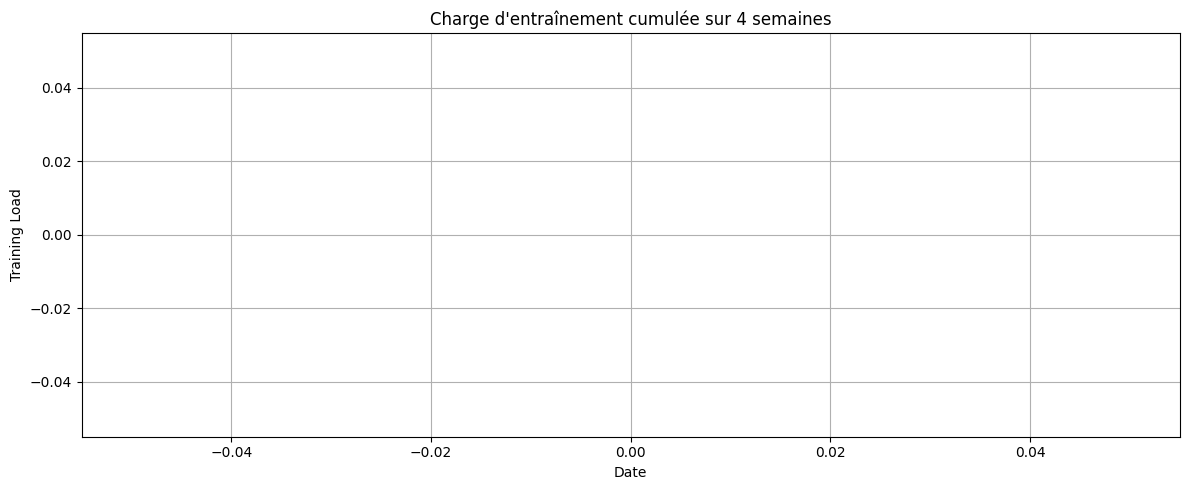

In [54]:
plot_variable_for_athlete(df=df_run,athlete_id="118945026",variable="pct_time_Z1",title="Charge d'entraînement cumulée sur 4 semaines",ylabel="Training Load")

In [ ]:
# Sauvegarde des DataFrames dans des fichiers CSV

df_run.to_csv("Data/processed/df_run.csv", index=False)
df_athletes_stats.to_csv("Data/processed/df_athletes_stats.csv", index=False)